In [329]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [331]:
from cv_functions import *

In [333]:
from skimage.restoration import unwrap_phase

In [335]:
def get_phase_from_image(img, mask_radius = 15, filter_radius = 15):
    fft = np.fft.fftshift(np.fft.fft2(img))
    spectrum = np.log(1 + np.abs(fft))
    f_x, f_y = find_plus_one_order_position(spectrum, mask_radius = mask_radius)
    filtered_spectrum = filter_spectrum(fft, f_x, f_y, radius=filter_radius)
    centered_spectrum = center_spectrum(filtered_spectrum, f_x, f_y)
    complex_field = np.fft.ifft2(np.fft.ifftshift(centered_spectrum))
    phase_wrapped = np.angle(complex_field)
    phase_unwrapped = unwrap_phase(phase_wrapped)
    return phase_unwrapped

In [337]:
img = cv2.imread(r"Images\Image 3\Blood Cells 3.bmp", cv2.IMREAD_GRAYSCALE)

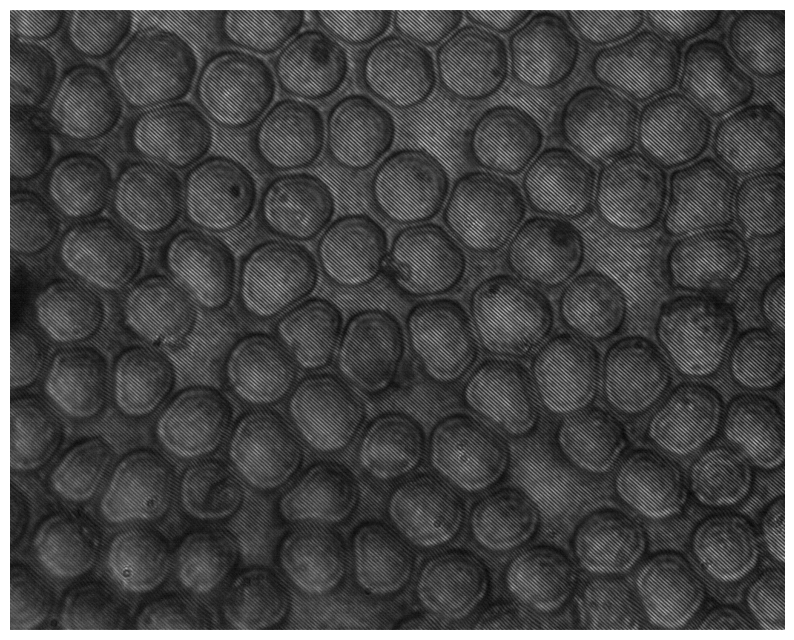

In [339]:
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [582]:
phase = get_phase_from_image(img, filter_radius = 100)

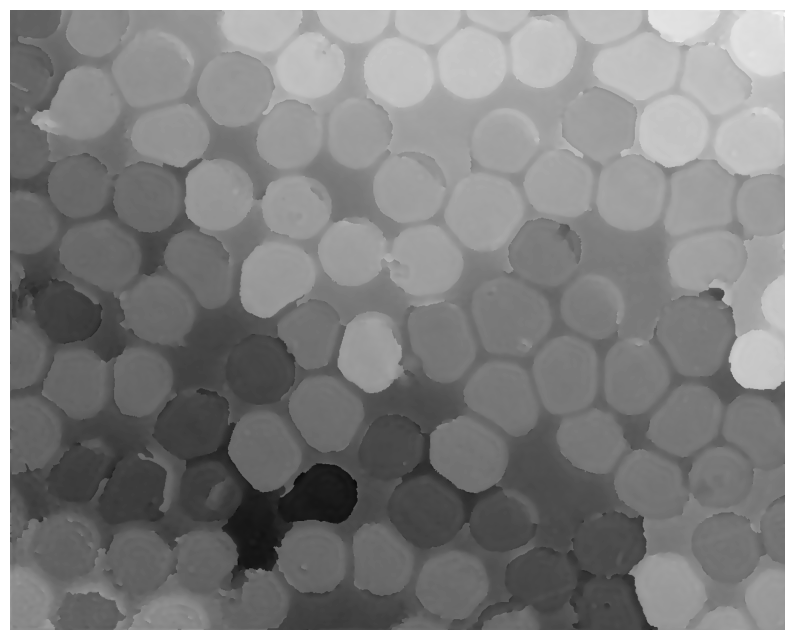

In [583]:
plt.figure(figsize=(10, 10))
plt.imshow(phase, cmap='gray')
plt.axis('off')
plt.show()

In [586]:
normalized = cv2.normalize(phase, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

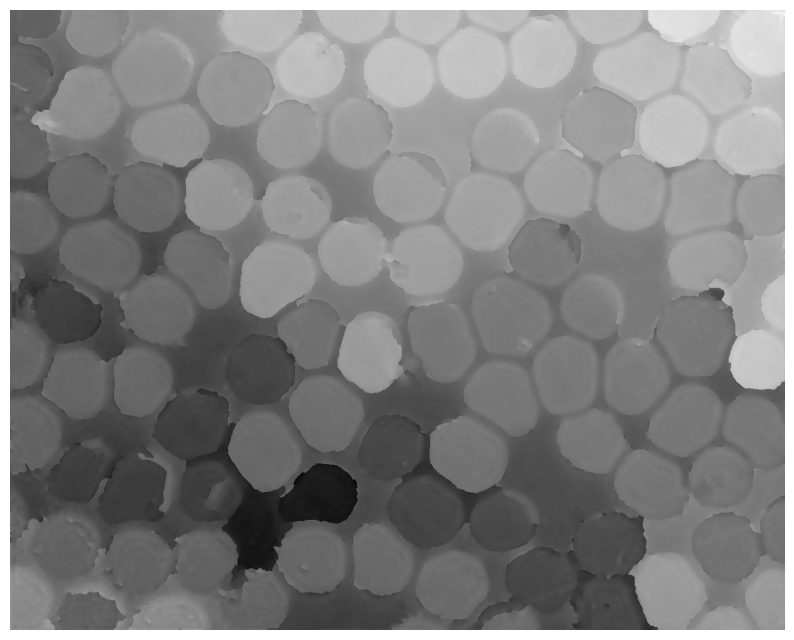

In [588]:
plt.figure(figsize=(10, 10))
plt.imshow(normalized, cmap='gray')
plt.axis('off')
plt.show()

In [590]:
cv2.imwrite("phase_cells.png", normalized)

True

In [592]:
edges = cv2.Canny(normalized, 8, 18)

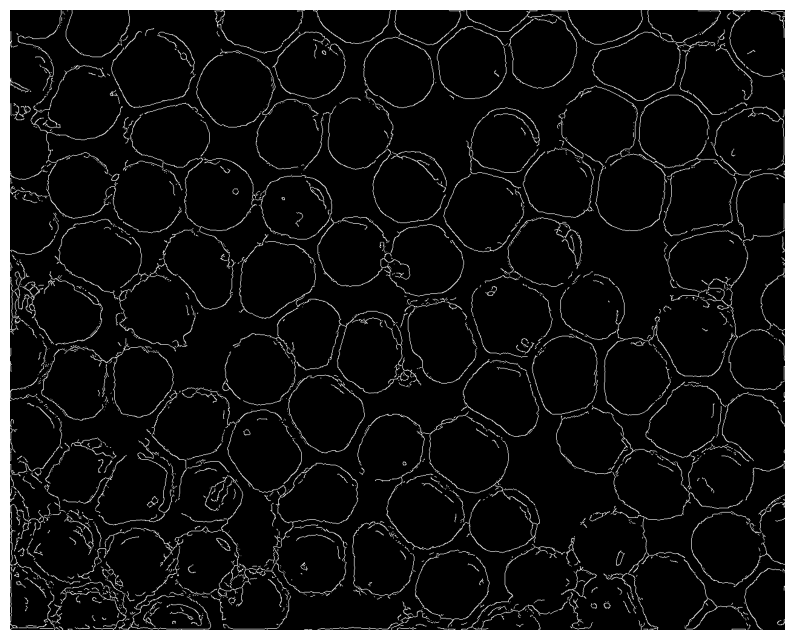

In [594]:
plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

In [596]:
cv2.imwrite("edges.png", edges)

True

In [598]:
kernel = np.ones((2, 2), np.uint8)
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=10)
dilated = cv2.dilate(closed, kernel, iterations=1)

In [600]:
kernel = np.ones((2, 2), np.uint8)
dilation = cv2.dilate(edges, kernel, iterations = 8)
closing = cv2.morphologyEx(dilation, cv2.MORPH_CLOSE, kernel, iterations = 1)
cv2.imwrite("Images/contours.png", closing)

True

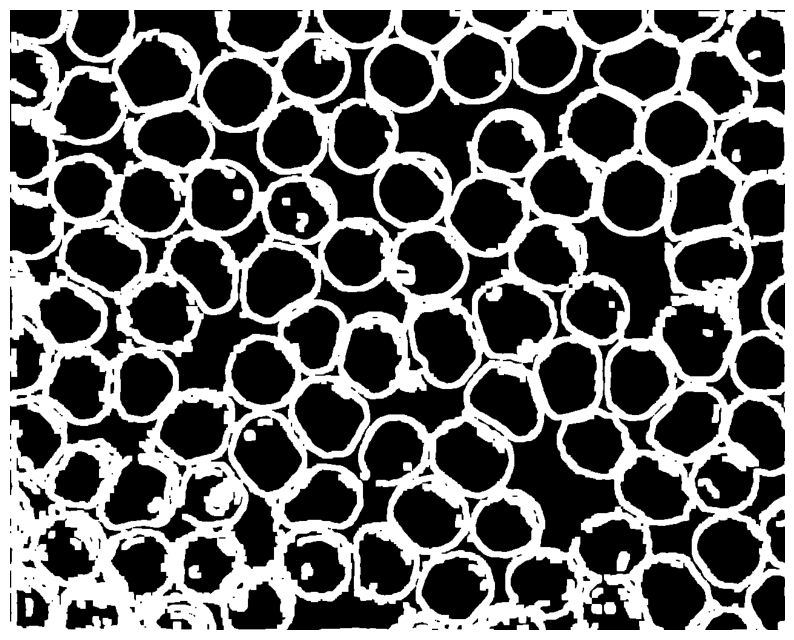

In [602]:
plt.figure(figsize=(10, 10))
plt.imshow(closing, cmap='gray')
plt.axis('off')
plt.show()

In [361]:
cv2.imwrite("closing.png", dilated)

True

In [604]:
def detect_erythrocytes(contour_img, original_img, min_area=500, max_area=10000, padding=20, 
                             circularity_threshold=0.5, solidity_threshold=0.7, eccentricity_threshold=0.9):

    inverted = cv2.bitwise_not(contour_img)
    _, binary = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    result = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
    erythrocytes = []
    cell_images = []
    cell_masks = []  # список бинарных масок контуров
    h, w = contour_img.shape
    
    erythrocytes_count = 0
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if area < min_area or area > max_area:
            continue
            
        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        
        if (left <= padding or top <= padding or left + width >= w-padding or top + height >= h-padding):
            continue
            
        mask = (labels == i).astype(np.uint8) * 255
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            contour = contours[0]
            
            # Периметр и площадь
            perimeter = cv2.arcLength(contour, True)
            area_contour = cv2.contourArea(contour)
            
            if perimeter > 0:
                circularity = 4 * np.pi * area_contour / (perimeter * perimeter)
            else:
                circularity = 0
            
            epsilon = 0.02 * perimeter
            approx = cv2.approxPolyDP(contour, epsilon, True)
            
            hull = cv2.convexHull(contour)
            hull_area = cv2.contourArea(hull)
            solidity = area_contour / hull_area if hull_area > 0 else 0
            
            if len(contour) >= 5:
                ellipse = cv2.fitEllipse(contour)
                (center, axes, orientation) = ellipse
                major_axis = max(axes)
                minor_axis = min(axes)
                eccentricity = np.sqrt(1 - (minor_axis/major_axis)**2) if major_axis > 0 else 0
            else:
                eccentricity = 1
            
            if circularity > circularity_threshold and solidity > solidity_threshold and eccentricity < eccentricity_threshold:
                erythrocytes_count += 1
            
                center_x = left + width // 2
                center_y = top + height // 2
                
                square_size = max(width, height) + 2 * padding
                
                crop_left = max(0, center_x - square_size // 2)
                crop_top = max(0, center_y - square_size // 2)
                crop_right = min(w, crop_left + square_size)
                crop_bottom = min(h, crop_top + square_size)
                
                if crop_right - crop_left < square_size:
                    crop_left = max(0, crop_right - square_size)
                if crop_bottom - crop_top < square_size:
                    crop_top = max(0, crop_bottom - square_size)
                
                # Вырезаем изображение клетки
                cell_img = original_img[crop_top:crop_bottom, crop_left:crop_right]
                
                # Вырезаем бинарную маску контура
                cell_mask = mask[crop_top:crop_bottom, crop_left:crop_right]
                
                # Приводим к квадратному размеру при необходимости
                if cell_img.shape[0] != cell_img.shape[1]:
                    size = max(cell_img.shape)
                    
                    square_cell = np.zeros((size, size), dtype=np.uint8)
                    y_offset = (size - cell_img.shape[0]) // 2
                    x_offset = (size - cell_img.shape[1]) // 2
                    square_cell[y_offset:y_offset + cell_img.shape[0], 
                               x_offset:x_offset + cell_img.shape[1]] = cell_img
                    cell_img = square_cell
                    
                    square_mask = np.zeros((size, size), dtype=np.uint8)
                    square_mask[y_offset:y_offset + cell_mask.shape[0], 
                               x_offset:x_offset + cell_mask.shape[1]] = cell_mask
                    cell_mask = square_mask
                
                cell_info = {
                    'id': erythrocytes_count,
                    'area': area,
                    'circularity': circularity,
                    'solidity': solidity,
                    'eccentricity': eccentricity,
                    'centroid': (int(centroids[i][0]), int(centroids[i][1])),
                    'bbox': (left, top, width, height),
                    'crop_coords': (crop_left, crop_top, crop_right, crop_bottom)
                }
                
                erythrocytes.append(cell_info)
                cell_images.append(cell_img)
                cell_masks.append(cell_mask)
                
                color = (0, 255, 0) 
                
                cv2.rectangle(result, (left, top), (left+width, top+height), color, 2)
                cv2.putText(result, f"E{erythrocytes_count}", (int(centroids[i][0]), int(centroids[i][1])), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    
    print(f"{len(erythrocytes)} erythrocytes detected")
    
    return result, erythrocytes, cell_images, cell_masks

In [606]:
result, erythrocytes, cell_images, cell_masks = detect_erythrocytes(closing, img, padding = 25,  circularity_threshold = 0.5, solidity_threshold = 0.7, eccentricity_threshold = 0.9)

53 erythrocytes detected


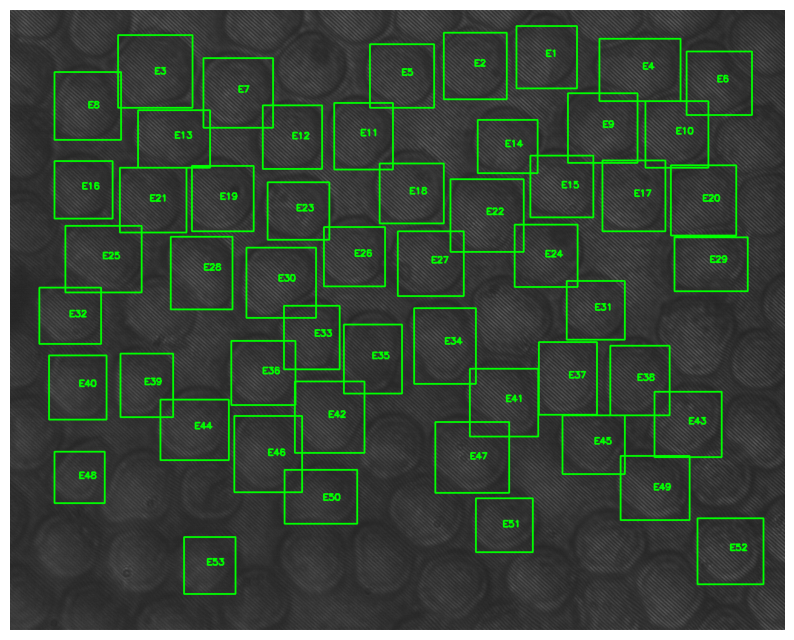

In [608]:
plt.figure(figsize=(10, 10))
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()

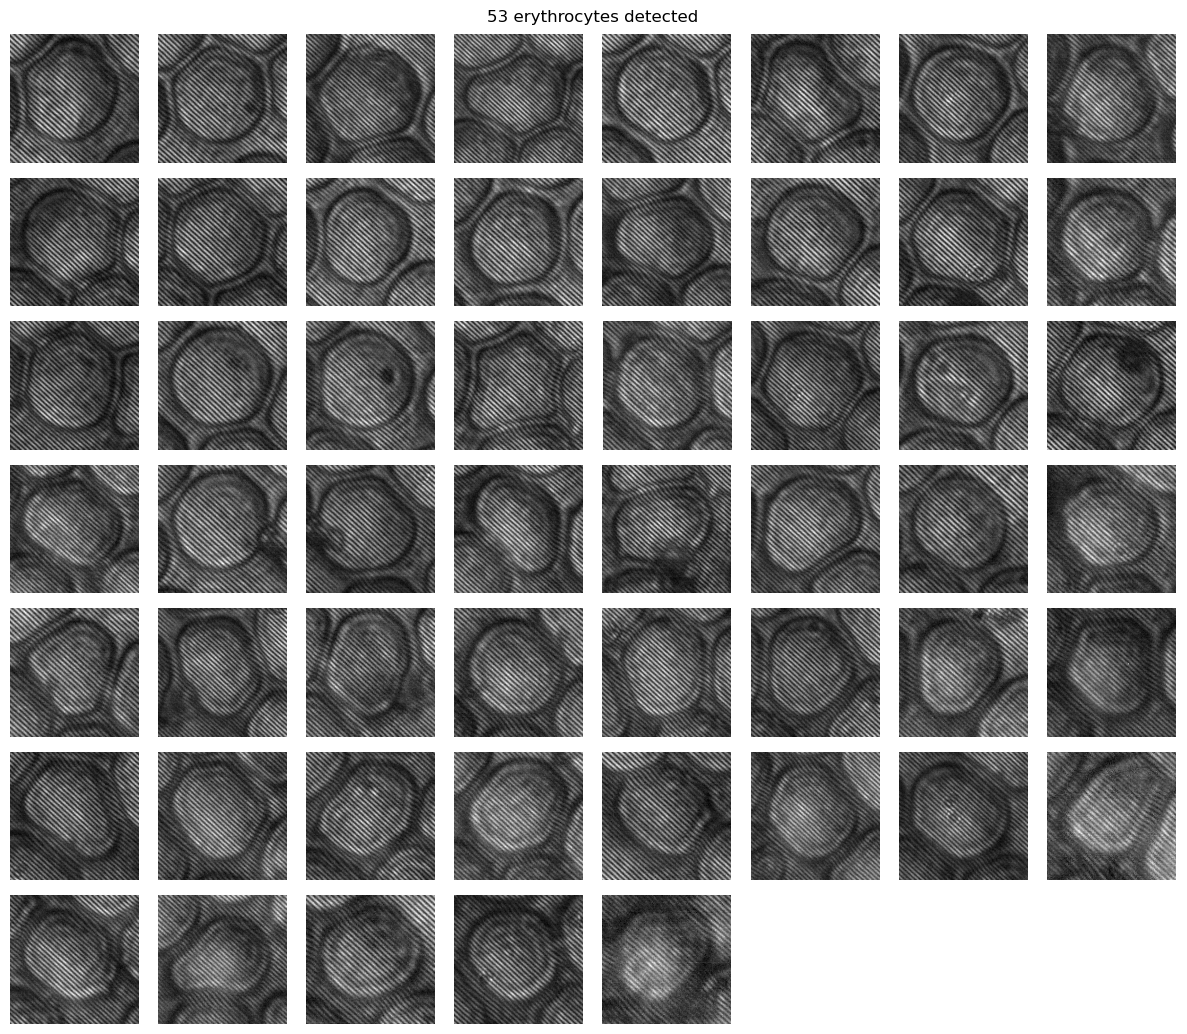

In [610]:
import matplotlib.pyplot as plt
import math

n = len(cell_images)

cols = math.ceil(math.sqrt(n))
cols = max(2, min(cols, 8))

rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = axes.flatten() if rows > 1 or cols > 1 else [axes]

for i in range(n):
    axes[i].imshow(cell_images[i], cmap='gray')
    axes[i].axis('off')

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'{n} erythrocytes detected')
plt.tight_layout()
plt.show()

In [616]:
import numpy as np
import cv2


def _fit_plane_robust(xs, ys, zs, n_iter=3, k=2.5):
    xs = xs.astype(np.float64); ys = ys.astype(np.float64); zs = zs.astype(np.float64)
    inliers = np.ones(len(zs), dtype=bool)
    coef = np.array([0.0, 0.0, np.median(zs) if len(zs) else 0.0])
    for _ in range(n_iter):
        if inliers.sum() < 3:
            break
        A = np.c_[xs[inliers], ys[inliers], np.ones(inliers.sum())]
        coef, *_ = np.linalg.lstsq(A, zs[inliers], rcond=None)
        resid = zs - (coef[0]*xs + coef[1]*ys + coef[2])
        s = np.std(resid[inliers])
        if s == 0:
            break
        inliers = np.abs(resid) < k*s
    return coef


def detect_erythrocytes(contour_img, original_img, min_area=500, max_area=10000, padding=20,
                        circularity_threshold=0.5, solidity_threshold=0.7, eccentricity_threshold=0.9,
                        skip_frac=0.2, min_skip= 3, ring_width=12):
 
    phase = original_img.astype(np.float64)
    phase_vis = cv2.normalize(phase, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    inverted = cv2.bitwise_not(contour_img)
    _, binary = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    result = cv2.cvtColor(phase_vis, cv2.COLOR_GRAY2BGR)
    erythrocytes = []
    cell_images = []
    h, w = contour_img.shape

    all_cells_mask = (labels > 0)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    erythrocytes_count = 0

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area or area > max_area:
            continue

        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]

        if (left <= padding or top <= padding or
                left + width >= w - padding or top + height >= h - padding):
            continue

        mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = contours[0]

        perimeter = cv2.arcLength(contour, True)
        area_contour = cv2.contourArea(contour)
        circularity = 4 * np.pi * area_contour / (perimeter * perimeter) if perimeter > 0 else 0

        hull_area = cv2.contourArea(cv2.convexHull(contour))
        solidity = area_contour / hull_area if hull_area > 0 else 0

        if len(contour) >= 5:
            (_, axes, _) = cv2.fitEllipse(contour)
            major_axis, minor_axis = max(axes), min(axes)
            eccentricity = np.sqrt(1 - (minor_axis / major_axis) ** 2) if major_axis > 0 else 0
        else:
            eccentricity = 1

        if not (circularity > circularity_threshold and
                solidity > solidity_threshold and
                eccentricity < eccentricity_threshold):
            continue

        erythrocytes_count += 1
        center_x = int(centroids[i][0])
        center_y = int(centroids[i][1])
        estimated_radius = int(np.sqrt(area_contour / np.pi))

        cell_pixels = phase[mask > 0]
        cell_mean = np.mean(cell_pixels)
        cell_median = np.median(cell_pixels)
        cell_min = np.min(cell_pixels)
        cell_max = np.max(cell_pixels)
        cell_std = np.std(cell_pixels)

        ring_skip = max(min_skip, int(skip_frac * estimated_radius))
        cell_mask_bin = (labels == i).astype(np.uint8)
        inner = cv2.dilate(cell_mask_bin, kernel, iterations=ring_skip)
        outer = cv2.dilate(cell_mask_bin, kernel, iterations=ring_skip + ring_width)
        ring = (outer > 0) & (inner == 0) & (~all_cells_mask)

        ys_bg, xs_bg = np.where(ring)
        zs_bg = phase[ring]
        keep = zs_bg < cell_median                    # отбросить пиксели уровня клетки в кольце
        xs_bg, ys_bg, zs_bg = xs_bg[keep], ys_bg[keep], zs_bg[keep]

        if len(xs_bg) >= 10:
            coef = _fit_plane_robust(xs_bg, ys_bg, zs_bg)
            substrate_height = coef[0] * center_x + coef[1] * center_y + coef[2]
            is_valid = substrate_height < cell_median
        else:
            coef = np.array([0.0, 0.0, float(cell_min)])
            substrate_height = cell_min
            is_valid = False

        square_size = max(width, height) + 2 * padding
        crop_left = max(0, center_x - square_size // 2)
        crop_top = max(0, center_y - square_size // 2)
        crop_right = min(w, crop_left + square_size)
        crop_bottom = min(h, crop_top + square_size)
        if crop_right - crop_left < square_size:
            crop_left = max(0, crop_right - square_size)
        if crop_bottom - crop_top < square_size:
            crop_top = max(0, crop_bottom - square_size)

        # маски в пределах выреза
        labels_crop = labels[crop_top:crop_bottom, crop_left:crop_right]
        cell_mask_crop = (labels_crop == i).astype(np.uint8)
        other_cells_crop = ((labels_crop > 0) & (labels_crop != i)).astype(np.uint8)

        cell_img = phase[crop_top:crop_bottom, crop_left:crop_right]
        cell_img_corrected = cell_img - substrate_height
        if cell_img.shape[0] != cell_img.shape[1]:
            size = max(cell_img.shape)
            square_cell = np.zeros((size, size), dtype=np.float64)
            y_off = (size - cell_img.shape[0]) // 2
            x_off = (size - cell_img.shape[1]) // 2
            square_cell[y_off:y_off + cell_img.shape[0],
                        x_off:x_off + cell_img.shape[1]] = cell_img_corrected
            cell_img_corrected = square_cell

        cell_info = {
            'id': erythrocytes_count,
            'area': area,
            'circularity': circularity,
            'solidity': solidity,
            'eccentricity': eccentricity,
            'centroid': (center_x, center_y),
            'bbox': (left, top, width, height),
            'crop_coords': (crop_left, crop_top, crop_right, crop_bottom),
            'estimated_radius': estimated_radius,
            'ring_skip': ring_skip,
            'substrate_height': substrate_height,
            'plane_coef': coef,
            'cell_mask_crop': cell_mask_crop,
            'other_cells_crop': other_cells_crop,
            'substrate_is_valid': is_valid,
            'cell_mean': cell_mean,
            'cell_median': cell_median,
            'cell_min': cell_min,
            'cell_max': cell_max,
            'cell_std': cell_std,
            'height_above_substrate': cell_max - substrate_height
        }
        erythrocytes.append(cell_info)
        cell_images.append(cell_img_corrected)

        overlay = result.copy()
        overlay[ring] = (255, 0, 0)                   # кольцо фона — синим
        cv2.addWeighted(overlay, 0.4, result, 0.6, 0, result)

        color = (0, 255, 0) if is_valid else (0, 165, 255)
        cv2.drawContours(result, [contour], -1, color, 2)
        cv2.circle(result, (center_x, center_y), 3, (0, 0, 255), -1)
        cv2.putText(result, f"E{erythrocytes_count}", (left, top - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        cv2.putText(result, f"h={substrate_height:.4f}", (left, top + height + 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    print(f"{len(erythrocytes)} erythrocytes detected")
    valid_count = sum(1 for e in erythrocytes if e['substrate_is_valid'])
    print(f"{valid_count}/{len(erythrocytes)} with valid substrate")
    print(f"Phase range: [{phase.min():.4f}, {phase.max():.4f}]")

    return result, erythrocytes, cell_images

In [618]:
result, erythrocytes, cell_images = detect_erythrocytes(closing, phase, padding = 10)

54 erythrocytes detected
53/54 with valid substrate
Phase range: [-9.9523, 30.5983]


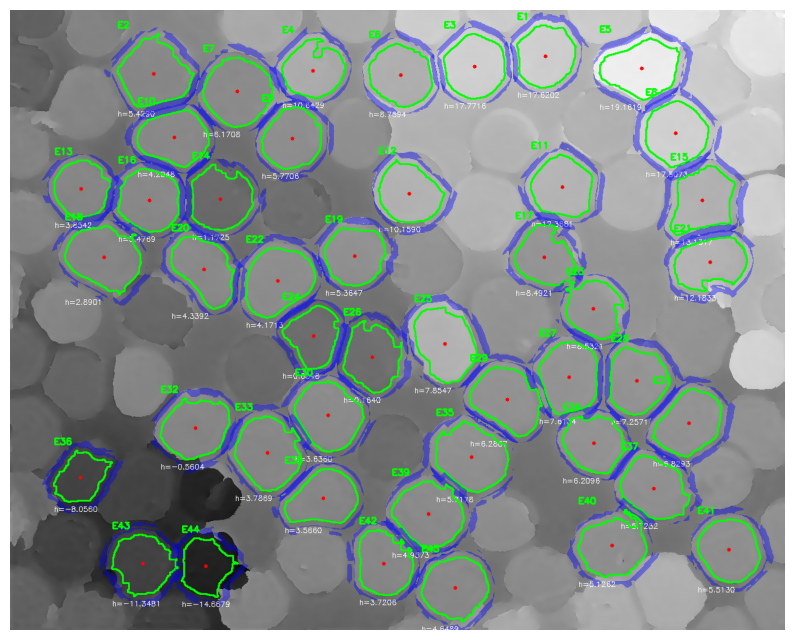

In [564]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

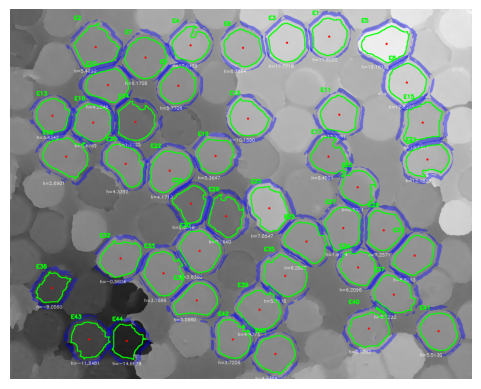

In [562]:

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.savefig("result.png", dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [230]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter
import trimesh

def get_3d_phase(phase, pixel_size=2.2, wavelength=0.65, zoom=80):
    h, w = phase.shape
    
    step = 1
    x = np.arange(0, w, step)
    X_3d, Y_3d = np.meshgrid(x, y)
    Z_3d = phase[::step, ::step]
    
    X_microns = X_3d * pixel_size / zoom
    Y_microns = Y_3d * pixel_size / zoom
    Z_microns = Z_3d * wavelength / (2 * np.pi)
    
    return X_microns, Y_microns, Z_microns

In [585]:
def build_surface_models_from_detection(original_img, erythrocytes, cell_images,
                                         pixel_size=2.2, wavelength=0.65, zoom=80,
                                         smooth_sigma=0.5, visual_scale=1, height_scale=1.0,
                                         output_dir='3D Models', padding_size=20, delta_n=0.20):

    os.makedirs(output_dir, exist_ok=True)
    
    models_info = []
    
    for idx, (erythrocyte, cell_img) in enumerate(zip(erythrocytes, cell_images)):
        cell_id = erythrocyte['id']
        
        substrate_height = erythrocyte['substrate_height']
        cell_median = erythrocyte['cell_median']
        is_valid = erythrocyte['substrate_is_valid']
        crop_coords = erythrocyte['crop_coords']
        crop_left, crop_top, crop_right, crop_bottom = crop_coords
        
        phase_crop = original_img[crop_top:crop_bottom, crop_left:crop_right].astype(np.float64)
        
        height_above_substrate = cell_median - substrate_height
        mid_plane_phase = substrate_height + height_above_substrate / 2.0
        phase_centered = phase_crop - mid_plane_phase
        
        if phase_centered.shape[0] != phase_centered.shape[1]:
            size = max(phase_centered.shape)
            square_phase = np.zeros((size, size), dtype=np.float64)
            y_off = (size - phase_centered.shape[0]) // 2
            x_off = (size - phase_centered.shape[1]) // 2
            square_phase[y_off:y_off + phase_centered.shape[0],
                        x_off:x_off + phase_centered.shape[1]] = phase_centered
            phase_centered = square_phase
        
        pixel_physical = pixel_size / zoom
        
        h_m, w_m = phase_centered.shape
        x = np.arange(w_m) * pixel_physical
        y = np.arange(h_m) * pixel_physical
        X, Y = np.meshgrid(x, y)
        
        Z = phase_centered * wavelength / (2 * np.pi * delta_n)
        Z_smoothed = gaussian_filter(Z, sigma=smooth_sigma)
        
        h_m, w_m = Z_smoothed.shape
        verts = []
        faces = []

        for i in range(h_m):
            for j in range(w_m):
                verts.append([X[i, j] * visual_scale,
                              Y[i, j] * visual_scale,
                              Z_smoothed[i, j] * visual_scale * height_scale])

        for i in range(h_m - 1):
            for j in range(w_m - 1):
                p1 = i * w_m + j
                p2 = i * w_m + (j + 1)
                p3 = (i + 1) * w_m + j
                p4 = (i + 1) * w_m + (j + 1)
                faces += [[p1, p2, p3], [p2, p4, p3]]

        min_z = np.min([v[2] for v in verts])
        base_thickness = 0.1 * visual_scale
        x_min = X.min() * visual_scale
        x_max = X.max() * visual_scale
        y_min = Y.min() * visual_scale
        y_max = Y.max() * visual_scale

        base_verts = [
            [x_min, y_min, min_z - base_thickness],
            [x_max, y_min, min_z - base_thickness],
            [x_max, y_max, min_z - base_thickness],
            [x_min, y_max, min_z - base_thickness],
            [x_min, y_min, min_z],
            [x_max, y_min, min_z],
            [x_max, y_max, min_z],
            [x_min, y_max, min_z]
        ]

        offset = len(verts)
        base_faces = [
            [offset, offset+1, offset+2], [offset, offset+2, offset+3],
            [offset+4, offset+6, offset+5], [offset+4, offset+7, offset+6],
            [offset+1, offset+5, offset+6], [offset+1, offset+6, offset+2],
            [offset+2, offset+6, offset+7], [offset+2, offset+7, offset+3],
            [offset+3, offset+7, offset+4], [offset+3, offset+4, offset]
        ]

        all_verts = verts + base_verts
        all_faces = faces + base_faces

        mesh = trimesh.Trimesh(vertices=all_verts, faces=all_faces)

        validity_tag = "valid" if is_valid else "invalid"
        filename = os.path.join(output_dir, f"erythrocyte_{cell_id:03d}_{validity_tag}_surface.stl")
        mesh.export(filename)

        verts_arr = np.array(all_verts)
        diameter = max(np.ptp(verts_arr[:, 0]), np.ptp(verts_arr[:, 1]))
        volume = mesh.volume if mesh.is_watertight else np.nan

        substrate_um = substrate_height * wavelength / (2 * np.pi * delta_n)
        mid_plane_um = mid_plane_phase * wavelength / (2 * np.pi * delta_n)
        height_um = height_above_substrate * wavelength / (2 * np.pi * delta_n)

        print(f"  Cell {cell_id}: {os.path.basename(filename)}")
        print(f"    Z range: [{verts_arr[:, 2].min():.4f}, {verts_arr[:, 2].max():.4f}] µm")
        print(f"    Diameter: {diameter:.2f} µm")
        if not np.isnan(volume):
            print(f"    Volume: {volume:.2f} µm³")

        models_info.append({
            'id': cell_id,
            'filename': filename,
            'mesh': mesh,
            'diameter_um': diameter,
            'volume_um3': volume,
            'substrate_height_um': substrate_um,
            'mid_plane_um': mid_plane_um,
            'height_above_substrate_um': height_um,
            'substrate_is_valid': is_valid
        })
    
    print(f"\nBuilt {len(models_info)} surface models")
    print(f"Models saved to: {output_dir}")
    
    return models_info

In [621]:
def build_mirrored_models_from_detection(original_img, erythrocytes, cell_images,
                                          pixel_size=2.2, wavelength=0.65, zoom=80,
                                          smooth_sigma=0.5, visual_scale=1, height_scale=1.0,
                                          output_dir='3D Models', padding_size=20, delta_n=0.40,
                                          crop_by_contour=False, contour_dilate=15):


    os.makedirs(output_dir, exist_ok=True)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    models_info = []

    for idx, (erythrocyte, cell_img) in enumerate(zip(erythrocytes, cell_images)):
        cell_id = erythrocyte['id']
        substrate_height = erythrocyte['substrate_height']
        cell_median = erythrocyte['cell_median']
        is_valid = erythrocyte['substrate_is_valid']
        crop_coords = erythrocyte['crop_coords']
        crop_left, crop_top, crop_right, crop_bottom = crop_coords

        phase_crop = original_img[crop_top:crop_bottom, crop_left:crop_right].astype(np.float64)

        # --- высота от подложки: полная толщина клетки ---
        phase_above_substrate = phase_crop - substrate_height
        phase_above_substrate[phase_above_substrate < 0] = 0

        # --- обрезка по контуру клетки (опционально) ---
        if crop_by_contour:
            cmask = erythrocyte.get('cell_mask_crop')
            if cmask is not None:
                cmask = cmask.astype(np.uint8)
                if contour_dilate > 0:
                    cmask = cv2.dilate(cmask, kernel, iterations=contour_dilate)
                if cmask.shape != phase_above_substrate.shape:
                    cmask = cv2.resize(cmask, (phase_above_substrate.shape[1],
                                               phase_above_substrate.shape[0]),
                                       interpolation=cv2.INTER_NEAREST)
                phase_above_substrate[cmask == 0] = 0      # оставить только область контура

        mask_crop = (phase_above_substrate > 0).astype(np.uint8)
        if np.sum(mask_crop) < 10:
            mask_crop = np.ones_like(phase_above_substrate, dtype=np.uint8)

        if phase_above_substrate.shape[0] != phase_above_substrate.shape[1]:
            size = max(phase_above_substrate.shape)
            square_phase = np.zeros((size, size), dtype=np.float64)
            square_mask = np.zeros((size, size), dtype=np.uint8)
            y_off = (size - phase_above_substrate.shape[0]) // 2
            x_off = (size - phase_above_substrate.shape[1]) // 2
            square_phase[y_off:y_off + phase_above_substrate.shape[0],
                         x_off:x_off + phase_above_substrate.shape[1]] = phase_above_substrate
            square_mask[y_off:y_off + mask_crop.shape[0],
                        x_off:x_off + mask_crop.shape[1]] = mask_crop
            phase_above_substrate = square_phase
            mask_crop = square_mask

        pixel_physical = pixel_size / zoom
        h_m, w_m = phase_above_substrate.shape
        x = np.arange(w_m) * pixel_physical
        y = np.arange(h_m) * pixel_physical
        X, Y = np.meshgrid(x, y)

        Z = phase_above_substrate * wavelength / (2 * np.pi * delta_n)   # полная толщина
        Z_smoothed = gaussian_filter(Z, sigma=smooth_sigma)

        if mask_crop.shape != Z_smoothed.shape:
            mask_crop = cv2.resize(mask_crop, (Z_smoothed.shape[1], Z_smoothed.shape[0]))
            mask_crop = (mask_crop > 0.5).astype(np.uint8)

        Z_masked = Z_smoothed * mask_crop
        Z_masked[Z_masked == 0] = np.nan
        Z_half = Z_masked / 2.0

        max_positive = np.nanmax(Z_half)
        substrate_um = substrate_height * wavelength / (2 * np.pi * delta_n)
        height_above_substrate = cell_median - substrate_height
        height_um = height_above_substrate * wavelength / (2 * np.pi * delta_n)

        h_m, w_m = Z_half.shape
        verts = []
        faces = []
        v_top = {}
        v_bot = {}
        for i in range(h_m):
            for j in range(w_m):
                if not np.isnan(Z_half[i, j]) and mask_crop[i, j] > 0:
                    v_top[(i, j)] = len(verts)
                    verts.append([X[i, j] * visual_scale,
                                  Y[i, j] * visual_scale,
                                  Z_half[i, j] * visual_scale * height_scale])
        for i in range(h_m):
            for j in range(w_m):
                if not np.isnan(Z_half[i, j]) and mask_crop[i, j] > 0:
                    v_bot[(i, j)] = len(verts)
                    verts.append([X[i, j] * visual_scale,
                                  Y[i, j] * visual_scale,
                                  -Z_half[i, j] * visual_scale * height_scale])
        for i in range(h_m - 1):
            for j in range(w_m - 1):
                if ((i, j) in v_top and (i, j+1) in v_top and
                    (i+1, j) in v_top and (i+1, j+1) in v_top):
                    p1, p2, p3, p4 = v_top[(i, j)], v_top[(i, j+1)], v_top[(i+1, j)], v_top[(i+1, j+1)]
                    faces += [[p1, p2, p3], [p2, p4, p3]]
                if ((i, j) in v_bot and (i, j+1) in v_bot and
                    (i+1, j) in v_bot and (i+1, j+1) in v_bot):
                    p1, p2, p3, p4 = v_bot[(i, j)], v_bot[(i, j+1)], v_bot[(i+1, j)], v_bot[(i+1, j+1)]
                    faces += [[p1, p3, p2], [p2, p3, p4]]
        boundary = []
        for i in range(h_m):
            for j in range(w_m):
                if (i, j) in v_top:
                    if i == 0 or i == h_m - 1 or j == 0 or j == w_m - 1:
                        boundary.append((i, j))
                    elif ((i, j+1) not in v_top or (i, j-1) not in v_top or
                          (i+1, j) not in v_top or (i-1, j) not in v_top):
                        boundary.append((i, j))
        for (i, j) in boundary:
            if (i, j) not in v_top:
                continue
            t1 = v_top[(i, j)]
            b1 = v_bot[(i, j)]
            if (i, j+1) in boundary and (i, j+1) in v_top:
                t2, b2 = v_top[(i, j+1)], v_bot[(i, j+1)]
                faces += [[t1, b1, b2], [t1, b2, t2]]
            if (i+1, j) in boundary and (i+1, j) in v_top:
                t2, b2 = v_top[(i+1, j)], v_bot[(i+1, j)]
                faces += [[t1, b1, b2], [t1, b2, t2]]
        if len(verts) == 0:
            continue
        mesh = trimesh.Trimesh(vertices=verts, faces=faces)
        validity_tag = "valid" if is_valid else "invalid"
        filename = os.path.join(output_dir, f"erythrocyte_{cell_id:03d}_{validity_tag}_mirrored.stl")
        mesh.export(filename)
        verts_arr = np.array(verts)
        diameter = max(np.ptp(verts_arr[:, 0]), np.ptp(verts_arr[:, 1]))
        volume = mesh.volume if mesh.is_watertight else np.nan
        print(f"  Cell {cell_id}: {os.path.basename(filename)}")
        print(f"    Total thickness: {max_positive * 2:.4f} µm")
        print(f"    Diameter: {diameter:.2f} µm")
        if not np.isnan(volume):
            print(f"    Volume: {volume:.2f} µm³")
        models_info.append({
            'id': cell_id, 'filename': filename, 'mesh': mesh,
            'total_thickness_um': max_positive * 2,
            'diameter_um': diameter, 'volume_um3': volume,
            'substrate_height_um': substrate_um,
            'height_above_substrate_um': height_um,
            'substrate_is_valid': is_valid
        })

    print(f"\nBuilt {len(models_info)} mirrored models")
    print(f"Models saved to: {output_dir}")
    return models_info

In [623]:
build_mirrored_models_from_detection(phase, erythrocytes, cell_images, smooth_sigma=0, delta_n=0.4, crop_by_contour=True, contour_dilate=20)

  Cell 1: erythrocyte_001_valid_mirrored.stl
    Total thickness: 1.5303 µm
    Diameter: 3.27 µm
  Cell 2: erythrocyte_002_valid_mirrored.stl
    Total thickness: 1.5083 µm
    Diameter: 3.55 µm
  Cell 3: erythrocyte_003_valid_mirrored.stl
    Total thickness: 1.9671 µm
    Diameter: 3.91 µm
  Cell 4: erythrocyte_004_valid_mirrored.stl
    Total thickness: 2.2648 µm
    Diameter: 4.21 µm
  Cell 5: erythrocyte_005_valid_mirrored.stl
    Total thickness: 1.4236 µm
    Diameter: 3.41 µm
  Cell 6: erythrocyte_006_valid_mirrored.stl
    Total thickness: 1.6355 µm
    Diameter: 3.49 µm
  Cell 7: erythrocyte_007_valid_mirrored.stl
    Total thickness: 2.1002 µm
    Diameter: 3.69 µm
  Cell 8: erythrocyte_008_valid_mirrored.stl
    Total thickness: 2.4269 µm
    Diameter: 3.60 µm
  Cell 9: erythrocyte_009_valid_mirrored.stl
    Total thickness: 2.0283 µm
    Diameter: 3.69 µm
  Cell 10: erythrocyte_010_valid_mirrored.stl
    Total thickness: 1.2459 µm
    Diameter: 3.55 µm
  Cell 11: erythroc

[{'id': 1,
  'filename': '3D Models\\erythrocyte_001_valid_mirrored.stl',
  'mesh': <trimesh.Trimesh(vertices.shape=(21574, 3), faces.shape=(42606, 3))>,
  'total_thickness_um': np.float64(1.5302509369538686),
  'diameter_um': np.float64(3.2725000000000004),
  'volume_um3': nan,
  'substrate_height_um': np.float64(4.551323129206564),
  'height_above_substrate_um': np.float64(0.8176791729288894),
  'substrate_is_valid': np.True_},
 {'id': 2,
  'filename': '3D Models\\erythrocyte_002_valid_mirrored.stl',
  'mesh': <trimesh.Trimesh(vertices.shape=(23976, 3), faces.shape=(47394, 3))>,
  'total_thickness_um': np.float64(1.5082917610406525),
  'diameter_um': np.float64(3.5475000000000003),
  'volume_um3': nan,
  'substrate_height_um': np.float64(4.609379407752911),
  'height_above_substrate_um': np.float64(0.8439946453289089),
  'substrate_is_valid': np.True_},
 {'id': 3,
  'filename': '3D Models\\erythrocyte_003_valid_mirrored.stl',
  'mesh': <trimesh.Trimesh(vertices.shape=(27984, 3), face